- In this notebook: first peak SEA, peak counting, Pearson R correlation, flare grouping, flare statistics/correlation plots
- First peak SEA copied from workflow, with amended peak finding and flare end:

In [715]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter, peak_widths

from matplotlib import dates

from scipy.stats import pearsonr, spearmanr

In [15]:
flares = pd.read_csv("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210214_20260228_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(400)

In [16]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [17]:
#defining useful functions:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df


In [18]:
#retrieving flare spectrogram files and constructing dataframes in desired energy range. for ease, only using 
#flares where this is a file located that covers the entire flarelist flare duration - could extend to add case
#for combining multiple files to cover time range

df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [19]:
#flagging flares that appear to be SEP contaminated. this and no_file above reduce list from 400 -> 160

flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [20]:
checklist2 = list(np.where(np.array(flag2)==True)[0])

In [21]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

flarelist_refined = flarelist.loc[indices_refined]

- Finding flare durations:

In [22]:
#resampling to 1 second data
resampled_df_list = []
i=0
for df in df_list_refined:
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list.append(resampled_df)
    i+=1

In [23]:
#filtering flare data for durations

df_list_extrafiltered = []
for df in resampled_df_list:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 75, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 75, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [281]:
#function to find flare duration in each energy range
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=20)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=20)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 

        peak = np.max(flare_df['25.0 keV-50.0 keV'])
        peak_loc = flare_df.index[flare_df['25.0 keV-50.0 keV'] == peak][0]
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.2) & (flare_df.index<peak_loc)]

        found_start=False
        for time in start_df.index:
            start = flare_df.index.get_loc(flare_df.index[flare_df.index == time][0])
            points = flare_df['25.0 keV-50.0 keV'].iloc[start:start+20]
            if points.is_monotonic_increasing:
                estimated_start = time
                found_start=True
                break
        
        if not found_start:
            estimated_start=np.nan

        estimated_starts.append(estimated_start)

        if pd.notna(estimated_start):
            bkg = df['25.0 keV-50.0 keV'].loc[estimated_start - dt.timedelta(seconds=30)]
    
            end_df = flare_df[(flare_df['25.0 keV-50.0 keV']<0.2*peak) & (flare_df.index>peak_loc)]
            if not end_df.empty:
                estimated_end = end_df.index[0]
            else:
                estimated_end = np.nan
            
        else:
            estimated_end = np.nan

        estimated_ends.append(estimated_end)
        
        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            estimated_duration = (estimated_end - estimated_start).total_seconds()
            durations.append(estimated_duration)
        else:
            durations.append(np.nan)

        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            flare_df_50100 = flare_df.truncate(estimated_start, estimated_end)
    
            peak_50100 = np.max(flare_df_50100['50.0 keV-100.0 keV'])
            peak_loc_50100 = flare_df_50100.index[flare_df_50100['50.0 keV-100.0 keV'] == peak_50100][0]
    
            start_df_50100 = flare_df_50100[(flare_df_50100['50.0 keV-100.0 keV'].diff()>0.1) & (flare_df_50100.index<peak_loc_50100)]
    
            found_start_50100=False
            for time in start_df_50100.index:
                start = flare_df_50100.index.get_loc(flare_df_50100.index[flare_df_50100.index == time][0])
                points = flare_df_50100['50.0 keV-100.0 keV'].iloc[start:start+5]
                if points.is_monotonic_increasing:
                    estimated_start_50100 = time
                    found_start_50100=True
                    break
    
            if not found_start_50100:
                estimated_start_50100=np.nan
    
            end_df_50100 = flare_df_50100[(flare_df_50100['50.0 keV-100.0 keV']<2*np.mean(df['50.0 keV-100.0 keV'])) & (flare_df_50100.index>peak_loc_50100)]
            if not end_df_50100.empty:
                estimated_end_50100 = end_df_50100.index[0]
            else:
                estimated_end_50100 = np.nan
        
            estimated_starts_50100.append(estimated_start_50100)
            estimated_ends_50100.append(estimated_end_50100)
            
            if (pd.notna(estimated_start_50100)) & (pd.notna(estimated_end_50100)):
                estimated_duration_50100 = (estimated_end_50100 - estimated_start_50100).total_seconds()
                durations_50100.append(estimated_duration_50100)
            else:
                durations_50100.append(np.nan)
                
        else:
            durations_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [282]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [283]:
starts = times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

starts_50100 = times_50_100[0]
ends_50100 = times_50_100[1]
durations_50100 = times_50_100[2]

In [366]:
#resampling and normalising for peaks for ease (not truncating to start and end times)
resampled_df_list_peaks = []

for df in df_list_refined:
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_peaks.append(resampled_df)

#fixed df normalising to peak outside flare duration
i=0
normalised_df_list_peaks = []
for df in resampled_df_list_peaks:
    normalised_df = df.copy()
    df_flare = df.truncate(starts[i], ends[i])
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df_flare['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df_flare['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_peaks.append(normalised_df)
    i+=1

In [368]:
#changed peak finding prominence to background level
i=0
firstpeaks = []
firstpeaks_50100 = []
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):

        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg) #prominence=0.05*peak_counts)  distance = 10,
        firstpeaks.append(peaks[0])
    
        # start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
        # end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
        
        # df = df.truncate(start, end)
        # peak_counts=np.max(df['50.0 keV-100.0 keV'])
        # peaks, properties = find_peaks(df['50.0 keV-100.0 keV'], prominence=0.1*peak_counts) #distance=15,
        # firstpeaks_50100.append(peaks[0])
        
    i+=1

In [371]:
#aligning to first peaks:
timeshifted_df_list_firstpeak = []
i=0
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg)
        
        peak_time = df.index[peaks[0]]
        peak_time = pd.to_datetime(t(peak_time)).round('1s')
    
        total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()

        #made longer time range
        timeshifted_df.index = timeshifted_df.index - total_peak_time
        timeshifted_df = timeshifted_df.truncate(-2000, 1999)
        timeshifted_df_list_firstpeak.append(timeshifted_df)
    i+=1

#reindexing over a set length so that points align for averaging
firstpeak_list = []
for df in timeshifted_df_list_firstpeak:
    new_index = pd.Index(np.arange(-2000, 2000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list.append(df)

In [203]:
timeshifted_df_list_firstpeak_50100 = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    #
    df = df.truncate(start, end)
    peak_time = df.index[firstpeaks_50100[i]]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-200, 1799)
    timeshifted_df_list_firstpeak_50100.append(timeshifted_df)
    i+=1

firstpeak_list_50100 = []
for df in timeshifted_df_list_firstpeak_50100:
    new_index = pd.Index(np.arange(-200, 1800, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list_50100.append(df)

In [372]:
concat_band1_firstpeak = pd.concat((df['25.0 keV-50.0 keV'] for df in firstpeak_list), axis=1)
averaged_shape_flare_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.median(axis=1), columns=['25.0 keV-50.0 keV'])

std_2550_mean_firstpeak = concat_band1_firstpeak.std(axis=1)

upperlim_2550_firstpeak = median_2550_firstpeak['25.0 keV-50.0 keV']+std_2550_mean_firstpeak
lowerlim_2550_firstpeak = median_2550_firstpeak['25.0 keV-50.0 keV']-std_2550_mean_firstpeak

for i in np.arange(0, len(upperlim_2550_firstpeak), 1):
    if lowerlim_2550_firstpeak.iloc[i]<0:
        lowerlim_2550_firstpeak.iloc[i] = 0

In [193]:
concat_band2_firstpeak = pd.concat((df['50.0 keV-100.0 keV'] for df in firstpeak_list_50100), axis=1)
averaged_shape_flare_50100_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['50.0 keV-100.0 keV'])
median_50100_firstpeak = pd.DataFrame(concat_band2_firstpeak.median(axis=1), columns=['50.0 keV-100.0 keV'])

std_50100_mean_firstpeak = concat_band2_firstpeak.std(axis=1)

upperlim_50100_firstpeak = median_50100_firstpeak['50.0 keV-100.0 keV'] +std_50100_mean_firstpeak
lowerlim_50100_firstpeak = median_50100_firstpeak['50.0 keV-100.0 keV'] -std_50100_mean_firstpeak

for i in np.arange(0, len(upperlim_50100_firstpeak), 1):
    if lowerlim_50100_firstpeak.iloc[i]<0:
        lowerlim_50100_firstpeak.iloc[i] = 0

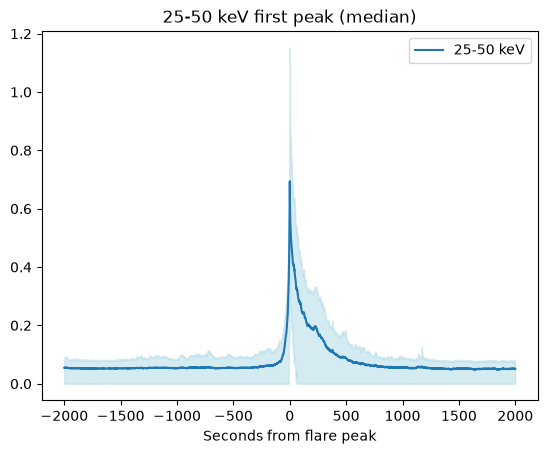

In [373]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (median)')
ax.legend()

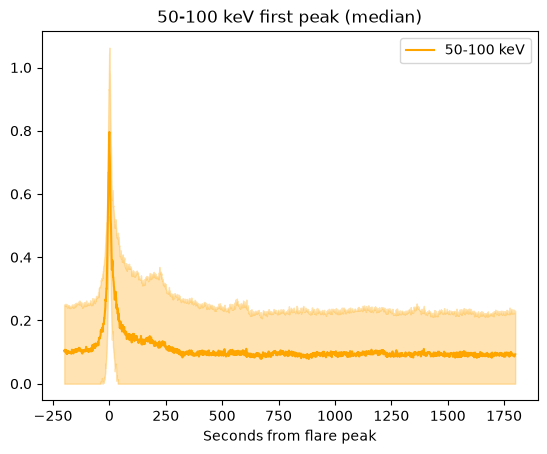

In [37]:
fig, ax = plt.subplots()

ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], label = '50-100 keV', color='orange')
ax.fill_between(median_50100_firstpeak.index, lowerlim_50100_firstpeak, upperlim_50100_firstpeak, color='orange', alpha=0.3)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('50-100 keV first peak (median)')
ax.legend()

In [400]:
#reduced filtering window
df_list_filtered = []
for df in resampled_df_list_peaks:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 15, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 15, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_filtered.append(df_filtered)

- Counting number of peaks in each flare. 1 = simple, 2 = moderate, 3+ = complex

In [723]:
i=0
peak_counts = []
firstpeaks_x = []
peak_separations = []
peak_fwhm = []
for df in df_list_filtered:
    if pd.notna(durations[i]):
        df.index = t(df.index)
        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
    
        df_flare = df.truncate(starts[i], ends[i])
        
        peaks, properties = find_peaks(df_flare['25.0 keV-50.0 keV'], distance = 10, prominence=2*bkg)
        peak_counts.append(len(peaks))
        firstpeaks_x.append(peaks[0])

        avg = np.mean(np.diff(peaks))
        peak_separations.append(avg)

        widths, width_heights, left_ips, right_ips = peak_widths(df_flare['25.0 keV-50.0 keV'], peaks, rel_height=0.5)
        peak_fwhm.append(np.mean(widths))

        df = resampled_df_list[i]
        df_plot = df.truncate(starts[i] - dt.timedelta(minutes=5), ends[i] + dt.timedelta(minutes=5))

        fig, ax = plt.subplots()
        ax.plot(df_plot.index, df_plot['25.0 keV-50.0 keV'])
        ax.scatter(df_flare.index[peaks], df_flare['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*', label=str(len(peaks))+' peaks')

        plt.axvline(starts[i], 0, 1, linestyle='dashed', color='lightcoral')
        plt.axvline(ends[i], 0, 1, linestyle='dashed', color='lightcoral')
        
        ax.legend()
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/peak_testing/flare"+str(i)+".png", bbox_inches='tight')
    else:
        peak_counts.append(np.nan)
    
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\1031117061.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
C:\Users\dearb\miniforge3\envs\sunpy\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\dearb\miniforge3\envs\sunpy\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(array([77., 36., 17.,  8.,  5.,  7.,  3.,  1.,  3.]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 9 artists>)

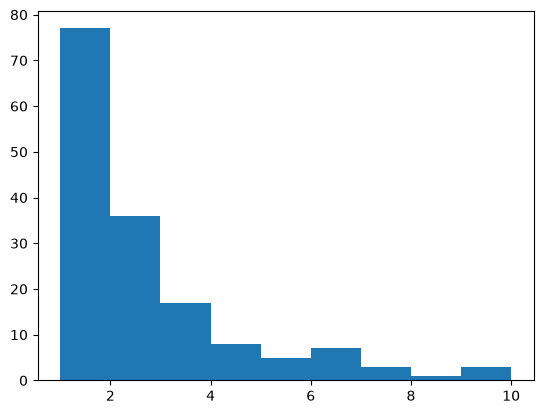

In [418]:
plt.hist(peak_counts, bins=9)

In [445]:
#tried using same start/end finding to get impulsive/'flare' period of median, but found by eye worked better
peak = np.max(median_2550_firstpeak['25.0 keV-50.0 keV'])
peak_loc = median_2550_firstpeak.index[median_2550_firstpeak['25.0 keV-50.0 keV'] == peak][0]

start_df = median_2550_firstpeak[(median_2550_firstpeak['25.0 keV-50.0 keV'].diff()>0.005) & (median_2550_firstpeak.index<peak_loc)]

found_start=False
for time in start_df.index:
    start = median_2550_firstpeak.index.get_loc(median_2550_firstpeak.index[median_2550_firstpeak.index == time][0])
    points = median_2550_firstpeak['25.0 keV-50.0 keV'].iloc[start:start+3]
    if points.is_monotonic_increasing:
        median_start = time
        found_start=True
        break

if not found_start:
    median_start=np.nan

end_df = median_2550_firstpeak[(median_2550_firstpeak['25.0 keV-50.0 keV']<0.2*np.max(median_2550_firstpeak['25.0 keV-50.0 keV'])) & (median_2550_firstpeak.index>peak_loc)]
if not end_df.empty:
    median_end = end_df.index[0]
else:
    median_end = np.nan

print(median_start, median_end)

-25 101


In [443]:
median_start = -100
median_end = 500

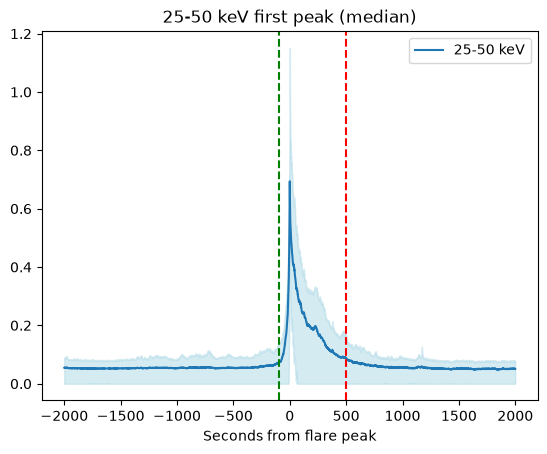

In [444]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (median)')
ax.legend()

plt.axvline(median_start, 0, 1, linestyle = 'dashed', color='green')
plt.axvline(median_end, 0, 1, linestyle = 'dashed', color='red')

In [645]:
timeshifted_df_list_corr = []
timeshifted_df_list_plot = []
pearsonr_corr =  []
median_refs = []
shifted_starts = []
shifted_ends = []
i=0
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):
        fig, ax = plt.subplots()
        
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], distance=10, prominence=2*bkg)
        
        peak_time = df.index[peaks[0]]
        peak_time = pd.to_datetime(t(peak_time)).round('1s')
        
        total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
        total_start = (starts[i] - dt.datetime(2004, 11, 25)).total_seconds()
        total_end = (ends[i] - dt.datetime(2004, 11, 25)).total_seconds()

        timeshifted_df_x = timeshifted_df.truncate(total_start, total_end)
        timeshifted_df_x.index = timeshifted_df_x.index - total_peak_time

        template = median_2550_firstpeak.truncate(total_start-total_peak_time, total_end-total_peak_time)

        shifted_starts.append(total_start-total_peak_time)
        shifted_ends.append(total_end - total_peak_time)
        
        new_index = pd.Index(np.arange(total_start-total_peak_time, total_end-total_peak_time, 1)) 
        df = timeshifted_df_x.set_index(timeshifted_df_x.index).reindex(new_index)
        timeshifted_df_list_corr.append(df)
        template = template.set_index(template.index).reindex(new_index)

        pr = pearsonr(df['25.0 keV-50.0 keV'], template['25.0 keV-50.0 keV'])[0]
        pearsonr_corr.append(pr)

        timeshifted_df = timeshifted_df.truncate(total_start-60, total_end+60)
        timeshifted_df.index = timeshifted_df.index - total_peak_time
        timeshifted_df_list_plot.append(timeshifted_df)

        template = median_2550_firstpeak.truncate(total_start-total_peak_time-60, total_end-total_peak_time+60)
        median_refs.append(template)
        
        ax.set_ylabel('ct/(keV s)')
        flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
        ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M")+'\nPearson r correlation = '+str(np.round(pr,2))+'\n'+str(peak_counts[i])+' peaks')
        
        ax.plot(template.index, template['25.0 keV-50.0 keV'], label='First peak normalised SEA')
        ax.fill_between(template.index, lowerlim_2550_firstpeak.truncate(total_start-total_peak_time-60,total_end-total_peak_time+60), upperlim_2550_firstpeak.truncate(total_start-total_peak_time-60,total_end-total_peak_time+60), color='lightblue', alpha=0.5)
        ax.plot(timeshifted_df.index, timeshifted_df['25.0 keV-50.0 keV'], label='25-50 keV')
        
        plt.axvline(total_start-total_peak_time, 0, 1, linestyle='dashed', color='lightcoral')
        plt.axvline(total_end-total_peak_time, 0, 1, linestyle='dashed', color='lightcoral')
        
        ax.set_xlabel('Seconds from flare start')
        ax.set_ylabel('Normalised counts')
        ax.set_ylim(-0.05, 1.05)
        
        ax.legend()
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/pearsonr/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\2326123660.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [724]:
flarelist_final_corr=flarelist_refined.iloc[list(np.where(pd.notna(durations)==True)[0])]

durations_f=[]
for dur in durations:
    if pd.notna(dur):
        durations_f.append(dur)

peak_counts_f=[]
for n in peak_counts:
    if pd.notna(n):
        peak_counts_f.append(n)

rise_times = []
decay_times = []
i=0
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):
        df=df.truncate(starts[i], ends[i])
        peak = np.max(df['25.0 keV-50.0 keV'])
        peak_loc = df.index[df['25.0 keV-50.0 keV'] == peak][0]

        rise = (peak_loc - starts[i]).total_seconds()
        decay = (ends[i] - peak_loc).total_seconds()

        rise_times.append(rise)
        decay_times.append(decay)
    i+=1
    
peak_ratios = []
max_peaks = []
i=0
for df in resampled_df_list_peaks:
    if pd.notna(durations[i]):
        df = df.truncate(starts[i], ends[i])
        peak = np.max(df['25.0 keV-50.0 keV'])
        peak_50100 = np.max(df['50.0 keV-100.0 keV'])
    
        ratio = peak_50100/peak
        peak_ratios.append(ratio)
        max_peaks.append(peak)
    i+=1

In [725]:
columns = ('flarelist_start', 'hxr_duration(seconds)','rise_time', 'decay_time', 'rise:decay', 'maximum','peak_ratio', 'average_peak_FWHM', 'average_peak_separation','number_of_peaks', 'pearsonr_with_median')
data=np.zeros((len(flarelist_final_corr), len(columns)))
stats_df = pd.DataFrame(data, columns = columns)

# for column in columns:
#     stats_df[column] = stats_df[column].astype(int)

stats_df['flarelist_start'] = stats_df['flarelist_start'].astype(str)
# stats_df['pearsonr_with_median'] = stats_df['pearsonr_with_median'].astype(float)
# stats_df['peak_ratio'] = stats_df['peak_ratio'].astype(float)
# stats_df['rise:decay'] = stats_df['rise:decay'].astype(float)
# stats_df['maximum'] = stats_df['maximum'].astype(float)
# stats_df['average_peak_separation'] = stats_df['average_peak_separation'].astype(float)
# stats_df['average_peak_separation'] = stats_df['average_peak_separation'].astype(float)

for i in range(len(flarelist_final_corr)):
    stats_df.loc[i, 'flarelist_start'] = flarelist_final_corr['start_UTC'].iloc[i]
    stats_df.loc[i, 'hxr_duration(seconds)'] = durations_f[i]
    stats_df.loc[i, 'number_of_peaks'] = peak_counts_f[i]
    stats_df.loc[i, 'pearsonr_with_median'] = pearsonr_corr[i]
    stats_df.loc[i, 'rise_time'] = rise_times[i]
    stats_df.loc[i, 'decay_time'] = decay_times[i]
    stats_df.loc[i, 'peak_ratio'] = peak_ratios[i]
    stats_df.loc[i, 'rise:decay'] = rise_times[i]/decay_times[i]
    stats_df.loc[i, 'maximum'] = max_peaks[i]
    stats_df.loc[i, 'average_peak_separation'] = peak_separations[i]
    stats_df.loc[i, 'average_peak_FWHM'] = peak_fwhm[i]

stats_df

,flarelist_start,hxr_duration(seconds),rise_time,decay_time,rise:decay,maximum,peak_ratio,average_peak_FWHM,average_peak_separation,number_of_peaks,pearsonr_with_median
0,2024-05-14T16:43:32.086,237.0,34.0,203.0,0.167488,3378.96,0.313623,13.405112,25.000000,6.0,0.827885
1,2022-09-29T11:44:36.211,134.0,46.0,88.0,0.522727,1991.20,0.240619,18.982625,15.000000,2.0,0.940814
2,2022-09-29T11:44:32.211,134.0,46.0,88.0,0.522727,1991.20,0.240619,18.982625,15.000000,2.0,0.940814
3,2024-10-03T12:04:29.984,342.0,120.0,222.0,0.540541,1433.36,0.134314,27.692539,34.666667,7.0,-0.408413
4,2024-05-17T12:22:04.029,273.0,155.0,118.0,1.313559,1387.28,0.192751,13.850247,30.000000,6.0,-0.491775
...,...,...,...,...,...,...,...,...,...,...,...
152,2022-03-28T10:55:28.252,386.0,40.0,346.0,0.115607,47.08,0.107477,34.959472,98.000000,2.0,0.642655
153,2024-09-28T09:41:46.251,1441.0,1203.0,238.0,5.054622,55.16,0.066352,12.275679,1170.000000,2.0,0.189808
154,2024-04-03T04:34:21.789,950.0,607.0,343.0,1.769679,45.44,0.063087,43.679998,235.500000,3.0,0.273758
155,2022-04-05T04:55:48.732,154.0,85.0,69.0,1.231884,47.44,0.185076,36.527935,NaN,1.0,0.475783


In [743]:
median_duration = median_end-median_start
print(median_duration)

median_peak = np.max(median_2550_firstpeak['25.0 keV-50.0 keV'])
median_peak_loc = median_2550_firstpeak.index[median_2550_firstpeak['25.0 keV-50.0 keV']==median_peak][0]

median_rise = median_peak_loc - median_start
median_decay = median_end - median_peak_loc
print(median_rise, median_decay)

peaks, properties = find_peaks(median_2550_firstpeak['25.0 keV-50.0 keV'], distance = 10, prominence=0.1)
widths, width_heights, left_ips, right_ips = peak_widths(median_2550_firstpeak['25.0 keV-50.0 keV'], peaks, rel_height=0.5)
median_2550_fwhm = widths[0]
print(len(peaks),median_2550_fwhm)

126
25 101
1 29.389366847190786


In [752]:
stats_df['average_peak_FWHM'].median()

np.float64(26.977626054112662)

In [618]:
spearmanr(stats_df['number_of_peaks'], stats_df['hxr_duration(seconds)'])

SignificanceResult(statistic=np.float64(0.5212226052502955), pvalue=np.float64(2.5835689001355755e-12))

Text(0, 0.5, 'Duration (seconds)')

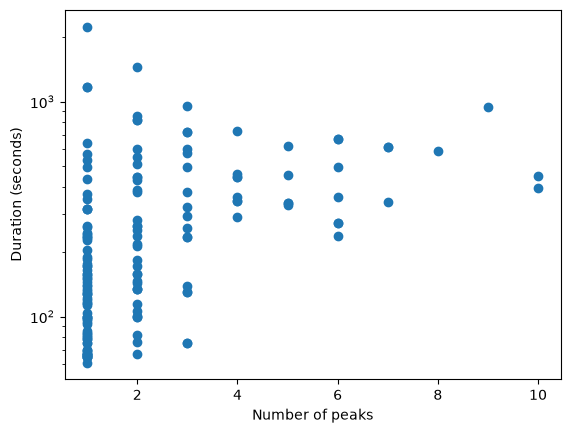

In [617]:
plt.scatter(stats_df['number_of_peaks'], stats_df['hxr_duration(seconds)'])
plt.yscale('log')
plt.xlabel('Number of peaks')
plt.ylabel('Duration (seconds)')

In [749]:
stats_df['number_of_peaks'].value_counts()

number_of_peaks
1.0     77
2.0     36
3.0     17
4.0      8
6.0      7
5.0      5
7.0      3
10.0     2
8.0      1
9.0      1
Name: count, dtype: int64

In [614]:
spearmanr(stats_df['number_of_peaks'], stats_df['maximum'])

SignificanceResult(statistic=np.float64(0.5188892780767983), pvalue=np.float64(3.3577738362809942e-12))

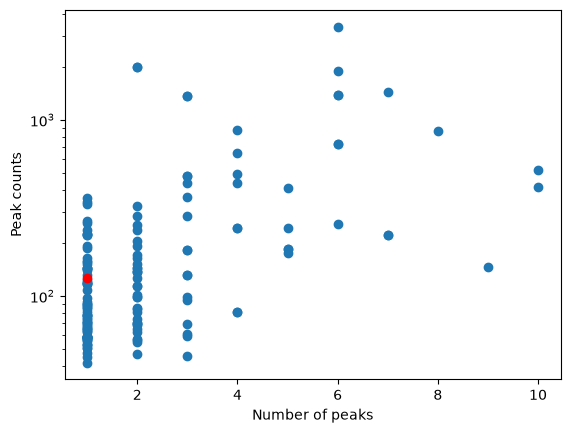

In [751]:
plt.scatter(stats_df['number_of_peaks'], stats_df['maximum'])
plt.yscale('log')
plt.xlabel('Number of peaks')
plt.ylabel('Peak counts')
plt.plot(1, median_duration, marker='o', color='red')
# plt.xscale('log')

In [582]:
pearsonr(np.log10(stats_df['rise:decay']), np.log10(stats_df['hxr_duration(seconds)']))

PearsonRResult(statistic=np.float64(-0.1901295960410857), pvalue=np.float64(0.017075509971689006))

In [584]:
spearmanr(stats_df['rise:decay'], stats_df['hxr_duration(seconds)'])

SignificanceResult(statistic=np.float64(-0.2154645075448179), pvalue=np.float64(0.00672636560770934))

Text(0, 0.5, 'Flare duration (seconds)')

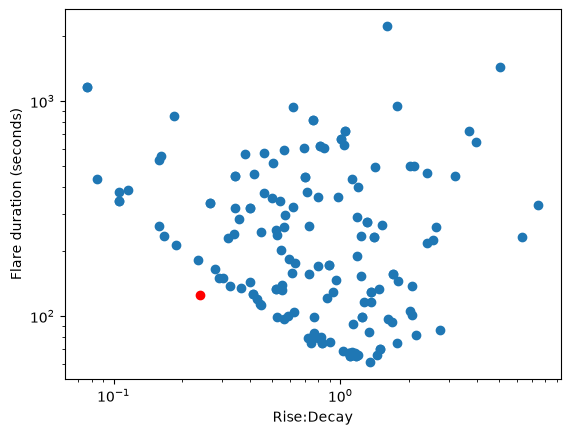

In [588]:
plt.scatter(stats_df['rise:decay'], stats_df['hxr_duration(seconds)'])
plt.plot(0.24, median_duration, marker='o', color='red')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Rise:Decay')
plt.ylabel('Flare duration (seconds)')
#plt.xlim(0, 3)

In [608]:
spearmanr(stats_df['rise_time'], stats_df['decay_time'])

SignificanceResult(statistic=np.float64(0.5421688931284421), pvalue=np.float64(2.2408573021032062e-13))

Text(0, 0.5, 'Decay time (seconds)')

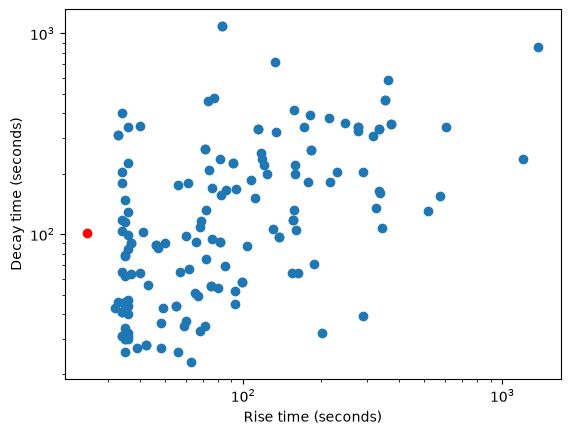

In [673]:
plt.scatter(stats_df['rise_time'], stats_df['decay_time'])
plt.plot(median_rise, median_decay, marker='o', color='red')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Rise time (seconds)')
plt.ylabel('Decay time (seconds)')

In [726]:
spearmanr(stats_df['hxr_duration(seconds)'], stats_df['average_peak_separation'], nan_policy='omit')

SignificanceResult(statistic=np.float64(0.6580497679077575), pvalue=np.float64(3.298034315462247e-11))

Text(0.5, 0, 'Duration (seconds)')

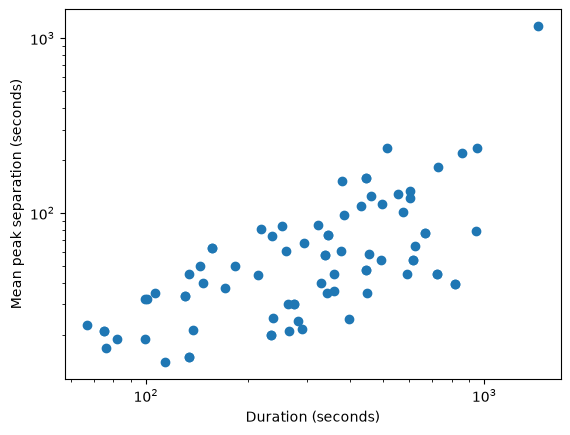

In [727]:
plt.scatter(stats_df['hxr_duration(seconds)'], stats_df['average_peak_separation'])
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Mean peak separation (seconds)')
plt.xlabel('Duration (seconds)')

In [731]:
spearmanr(stats_df['hxr_duration(seconds)'], stats_df['average_peak_FWHM'])

SignificanceResult(statistic=np.float64(0.5243595820882906), pvalue=np.float64(1.8105420939965092e-12))

Text(0.5, 0, 'Duration (seconds)')

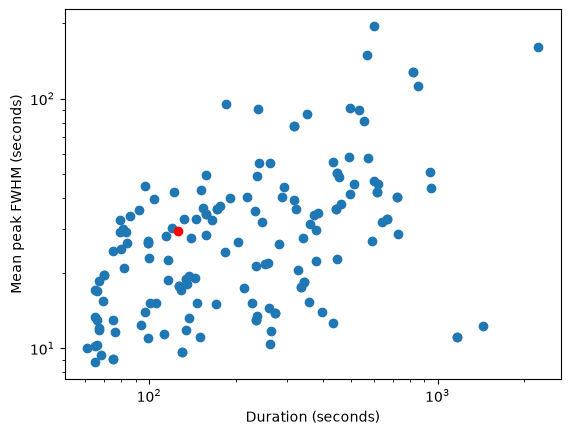

In [744]:
plt.scatter(stats_df['hxr_duration(seconds)'], stats_df['average_peak_FWHM'])
plt.plot(median_duration, median_2550_fwhm, marker='o', color='red')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Mean peak FWHM (seconds)')
plt.xlabel('Duration (seconds)')

In [734]:
spearmanr(stats_df['average_peak_FWHM'], stats_df['average_peak_separation'], nan_policy='omit')

SignificanceResult(statistic=np.float64(0.5968499246515387), pvalue=np.float64(5.126445859482878e-09))

Text(0, 0.5, 'Mean peak separation (seconds)')

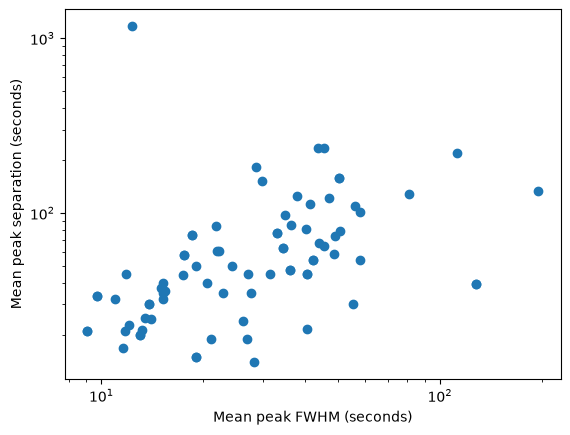

In [735]:
plt.scatter(stats_df['average_peak_FWHM'], stats_df['average_peak_separation'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mean peak FWHM (seconds)')
plt.ylabel('Mean peak separation (seconds)')

Text(0, 0.5, 'Peak counts')

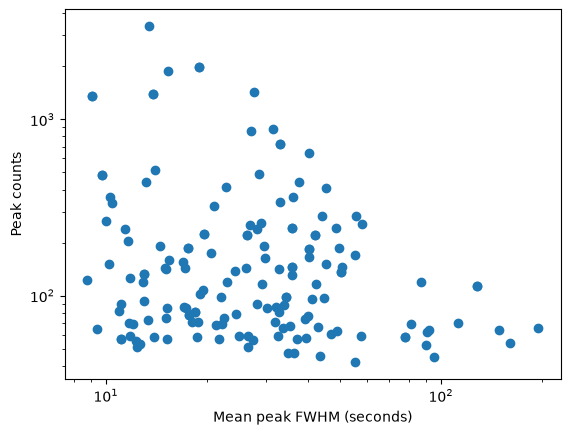

In [746]:
plt.scatter(stats_df['average_peak_FWHM'], stats_df['maximum'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mean peak FWHM (seconds)')
plt.ylabel('Peak counts')

In [544]:
stats_df['rise:decay'].median()

np.float64(0.8093841642228738)

In [524]:
sorted_pr_df = stats_df.sort_values('pearsonr_with_median', ascending=False)
sorted_pr_df.index

Index([ 62,   2,   1, 106,  37, 110,  84, 101,  91, 144,
       ...
        20,  22,  27,  86,   3,  26,  17,  10,   4,   5],
      dtype='int64', length=157)

In [525]:

i=0
for ind in sorted_pr_df.index:
    fig, ax = plt.subplots()
    
    timeshifted_df = timeshifted_df_list_plot[ind]

    template = median_refs[ind]
    
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_final_corr['start_UTC'].iloc[ind]).datetime
    ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M")+'\nPearson r correlation = '+str(np.round(sorted_pr_df['pearsonr_with_median'].loc[ind],2))+'\n'+str(peak_counts_f[ind])+' peaks')
    
    ax.plot(template.index, template['25.0 keV-50.0 keV'], label='First peak normalised SEA')
    ax.plot(timeshifted_df.index, timeshifted_df['25.0 keV-50.0 keV'], label='25-50 keV')
    
    ax.set_xlabel('Seconds from flare start')
    ax.set_ylabel('Normalised counts')
    ax.set_ylim(-0.05, 1.05)
    
    ax.legend()
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/pearsonr_sorted/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\2887590426.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [527]:
simple_by_peaks = np.where(np.array(peak_counts_f)<=2)[0]
complex_by_peaks = np.where(np.array(peak_counts_f)>2)[0]

simple_by_pearson = np.where(np.array(pearsonr_corr)>=0.7)[0]
complex_by_pearson = np.where(np.array(pearsonr_corr)<0.7)[0] 

In [534]:
print(len(simple_by_peaks), simple_by_peaks, len(simple_by_pearson), simple_by_pearson)

113 [  1   2  22  23  25  26  28  29  33  34  36  37  38  39  41  42  43  44
  46  47  48  52  53  54  55  56  57  59  60  61  62  63  64  65  67  68
  69  72  73  74  75  76  77  78  79  81  83  84  85  86  87  88  89  90
  91  92  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
 111 112 113 114 115 116 117 119 120 121 122 124 125 127 128 129 130 131
 132 133 134 135 136 138 139 140 141 142 143 144 145 146 147 148 149 150
 151 152 153 155 156] 76 [  0   1   2  12  23  25  28  29  33  37  38  41  42  43  44  45  46  47
  48  50  53  56  57  59  60  61  62  65  67  68  70  71  72  73  75  76
  77  78  84  85  87  89  91  92  93  94  95  96  99 100 101 102 103 105
 106 109 110 114 115 117 118 120 128 129 130 131 133 136 139 143 144 145
 147 149 151 156]


In [535]:
print(len(complex_by_peaks), complex_by_peaks, len(complex_by_pearson), complex_by_pearson)

44 [  0   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  24  27  30  31  32  35  40  45  49  50  51  58  66  70  71  80
  82  93  94 118 123 126 137 154] 81 [  3   4   5   6   7   8   9  10  11  13  14  15  16  17  18  19  20  21
  22  24  26  27  30  31  32  34  35  36  39  40  49  51  52  54  55  58
  63  64  66  69  74  79  80  81  82  83  86  88  90  97  98 104 107 108
 111 112 113 116 119 121 122 123 124 125 126 127 132 134 135 137 138 140
 141 142 146 148 150 152 153 154 155]


In [602]:
x = (set(complex_by_peaks)-set(complex_by_pearson)).union(set(complex_by_pearson)-set(complex_by_peaks))
agreed_complex_flares = set(complex_by_peaks)-x
len(agreed_complex_flares)

35

In [603]:
x = (set(simple_by_peaks)-set(simple_by_pearson)).union(set(simple_by_pearson)-set(simple_by_peaks))
agreed_simple_flares = set(simple_by_peaks)-x
len(agreed_simple_flares)

67

In [738]:
median_duration = median_end-median_start
print(median_duration)

median_peak = np.max(median_2550_firstpeak['25.0 keV-50.0 keV'])
median_peak_loc = median_2550_firstpeak.index[median_2550_firstpeak['25.0 keV-50.0 keV']==median_peak][0]

median_rise = median_peak_loc - median_start
median_decay = median_end - median_peak_loc
print(median_rise, median_decay)

126
25 101


In [546]:
rise_times_fp = []
decay_times_fp = []
i=0
for df in timeshifted_df_list_corr:
    rise = -df.index[0]
    decay = df.index[-1]

    rise_times_fp.append(rise)
    decay_times_fp.append(decay)
    i+=1

In [556]:
print(np.median(rise_times_fp), np.median(decay_times_fp))

40.0 142.0


In [561]:
np.where(np.array(np.round(pearsonr_corr, 2))==-0.43)

(array([17]),)

In [622]:
i=0
for df in timeshifted_df_list_plot:
    fig, ax = plt.subplots()

    template = median_refs[i]
    
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_final_corr['start_UTC'].iloc[ind]).datetime
    ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M")+'\nPearson r correlation = '+str(np.round(pr,2))+'\n'+str(peak_counts[i])+' peaks')
    
    ax.plot(template.index, template['25.0 keV-50.0 keV'], label='First peak normalised SEA')
    ax.plot(df.index, df['25.0 keV-50.0 keV'], label='25-50 keV')
    
    ax.set_xlabel('Seconds from flare start')
    ax.set_ylabel('Normalised counts')
    ax.set_ylim(-0.05, 1.05)
    
    ax.legend()
    if i in agreed_complex_flares:
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/sorted_complex_flares/flare"+str(i)+".png", bbox_inches='tight')
    if i in agreed_simple_flares:
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/sorted_simple_flares/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\2244464566.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [681]:
colours = ['red', 'yellow', 'green', 'purple', 'pink', 'navy', 'deeppink', 'lime', 'saddlebrown', 'gray']

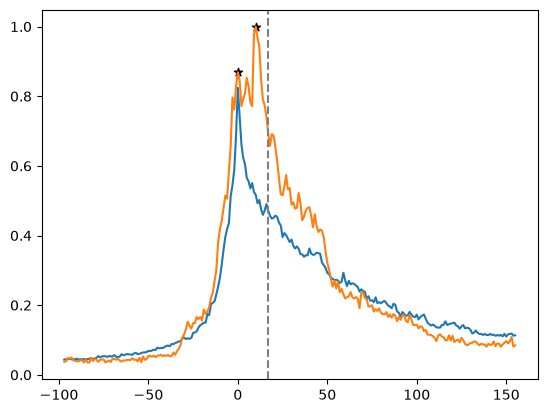

In [652]:
plt.plot(median_refs[62].index, median_refs[62]['25.0 keV-50.0 keV'])
plt.plot(timeshifted_df_list_plot[62].index, timeshifted_df_list_plot[62]['25.0 keV-50.0 keV'])
plt.axvline(17, 0, 1, linestyle='dashed', color='gray')

df = timeshifted_df_list_plot[62]
df_flare = df.truncate(shifted_starts[62], shifted_ends[62])

bkg = df['25.0 keV-50.0 keV'].loc[shifted_starts[62] - 30]
peaks, properties = find_peaks(df_flare['25.0 keV-50.0 keV'], distance=10, prominence=2*bkg)

plt.scatter(df_flare.index[peaks], df_flare['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*', label=str(len(peaks))+' peaks')

number of peaks: 3
average peak separation: 17.5 seconds


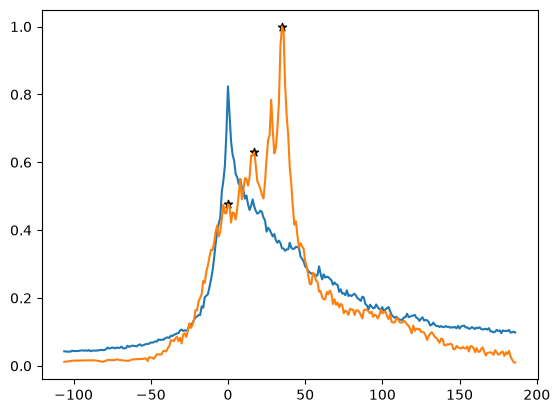

In [658]:
plt.plot(median_refs[60].index, median_refs[60]['25.0 keV-50.0 keV'])
plt.plot(timeshifted_df_list_plot[60].index, timeshifted_df_list_plot[60]['25.0 keV-50.0 keV'])

df = timeshifted_df_list_plot[60]
df_flare = df.truncate(shifted_starts[60], shifted_ends[60])

bkg = df['25.0 keV-50.0 keV'].loc[shifted_starts[60] - 30]
peaks, properties = find_peaks(df_flare['25.0 keV-50.0 keV'], distance=10, prominence=2*bkg)

plt.scatter(df_flare.index[peaks], df_flare['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*', label=str(len(peaks))+' peaks')
print('number of peaks: '+str(len(peaks))+'\naverage peak separation: '+str(np.mean(np.diff(peaks)))+' seconds')

number of peaks: 3
average peak separation: 32.0 seconds


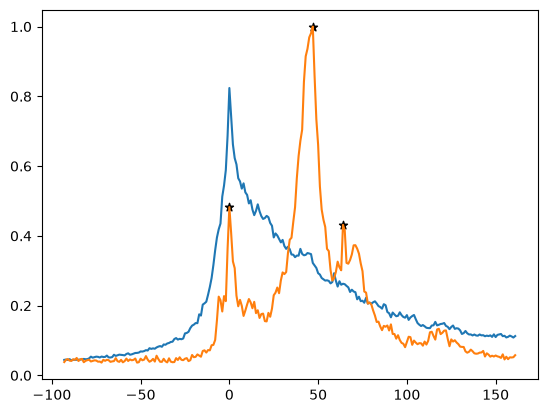

In [657]:
plt.plot(median_refs[74].index, median_refs[74]['25.0 keV-50.0 keV'])
plt.plot(timeshifted_df_list_plot[74].index, timeshifted_df_list_plot[74]['25.0 keV-50.0 keV'])

df = timeshifted_df_list_plot[74]
df_flare = df.truncate(shifted_starts[74], shifted_ends[74])

bkg = df['25.0 keV-50.0 keV'].loc[shifted_starts[74] - 30]
peaks, properties = find_peaks(df_flare['25.0 keV-50.0 keV'], distance=10, prominence=3*bkg)

plt.scatter(df_flare.index[peaks], df_flare['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*', label=str(len(peaks))+' peaks')

print('number of peaks: '+str(len(peaks))+'\naverage peak separation: '+str(np.mean(np.diff(peaks)))+' seconds')

number of peaks: 10
average peak separation: 25.0 seconds
average FWHM: 8.320776936478154


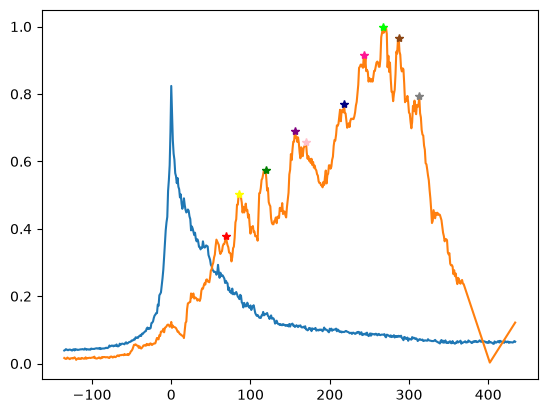

In [710]:
plt.plot(median_refs[17].index, median_refs[17]['25.0 keV-50.0 keV'])
plt.plot(timeshifted_df_list_plot[17].index, timeshifted_df_list_plot[17]['25.0 keV-50.0 keV'])

df = timeshifted_df_list_plot[17]
df_flare = df.truncate(shifted_starts[17], shifted_ends[17])

bkg = df['25.0 keV-50.0 keV'].loc[shifted_starts[17] - 30]
peaks, properties = find_peaks(df_flare['25.0 keV-50.0 keV'], distance=10, prominence=3*bkg)

#plt.scatter(df_flare.index[peaks], df_flare['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*', label=str(len(peaks))+' peaks')

i=0
for peak in peaks:
    plt.plot(df_flare.index[peak], df_flare['25.0 keV-50.0 keV'].iloc[peak], color=colours[i], marker='*')
    i+=1

widths, width_heights, left_ips, right_ips = peak_widths(df_flare['25.0 keV-50.0 keV'], peaks, rel_height=0.5)


# i=0
# fwhm = []
# for val in properties['prominences']:
#     plt.axhline(df_flare['25.0 keV-50.0 keV'].iloc[peaks[i]]-0.5*val, 0, 1, linestyle='dashed', color=colours[i])
#     peak_loc = df_flare.index[peaks[i]]
#     half_val = df_flare.index[peaks[i]] - 0.5*val
#     start_fwhm = df_flare['25.0 keV-50.0 keV'][(df_flare.index<peak_loc)&(df_flare['25.0 keV-50.0 keV']<half_val)].index[-1]
#     end_fwhm = df_flare['25.0 keV-50.0 keV'][(df_flare.index>peak_loc)&(df_flare['25.0 keV-50.0 keV']<half_val)].index[0]
#     fwhm.append(end_fwhm - start_fwhm)
#     i+=1

print('number of peaks: '+str(len(peaks))+'\naverage peak separation: '+str(np.median(np.diff(peaks)))+' seconds\naverage FWHM: '+str(np.median(widths)))

In [ ]:
half_val = 0.5*prominence
peak_loc = 
start_fwhm = flare_df['25.0 keV-50.0 keV'][(flare_df.index<peak_loc)&(flare_df['25.0 keV-50.0 keV']<half_val)][-1]
end_fwhm = flare_df['25.0 keV-50.0 keV'][(flare_df.index>peak_loc)&(flare_df['25.0 keV-50.0 keV']<half_val)][0]

In [692]:
peak_loc

np.float64(69.0)

In [700]:
end_fwhm = df_flare['25.0 keV-50.0 keV'][(df_flare.index>peak_loc)]
end_fwhm

70.0     0.362460
71.0     0.351628
72.0     0.345438
73.0     0.329577
74.0     0.328803
           ...   
370.0    0.228899
371.0    0.221840
372.0    0.214781
373.0    0.207722
374.0    0.200663
Name: 25.0 keV-50.0 keV, Length: 305, dtype: float64

In [698]:
end_fwhm = df_flare['25.0 keV-50.0 keV'][(df_flare.index>peak_loc)&(df_flare['25.0 keV-50.0 keV']<half_val)]
end_fwhm

Series([], Name: 25.0 keV-50.0 keV, dtype: float64)

In [694]:
half_val

np.float64(0.03733169038553155)

In [701]:
properties['prominences']

array([0.07466338, 0.13849477, 0.16093247, 0.16596161, 0.04951768,
       0.07040795, 0.07814509, 0.79933684, 0.18878616, 0.09439308])